Notebook 1 - Daily Returns

- fetching 3 years of price data for 5 stocks using yfinance

- calculating daily returns for each stock

- calculate portfolio daily return (equal weighted, 20% each)

- plot cumulative returns to see how each stock grew over time

/Users/shauryachandra/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  5 of 5 completed

(752, 5)


Ticker,AAPL,AMZN,JPM,MSFT,XOM
Date,,,,,
2023-01-03,122.982719,85.820000,123.735184,232.948257,94.790825
2023-01-04,124.251183,85.139999,124.889038,222.758377,95.066711
2023-01-05,122.933540,83.120003,124.861359,216.156311,97.193733
2023-01-06,127.456749,86.080002,127.250656,218.703751,98.368484
2023-01-09,127.977928,87.360001,126.724823,220.833130,96.535164



Missing Values: 
Ticker
AAPL    0
AMZN    0
JPM     0
MSFT    0
XOM     0
dtype: int64


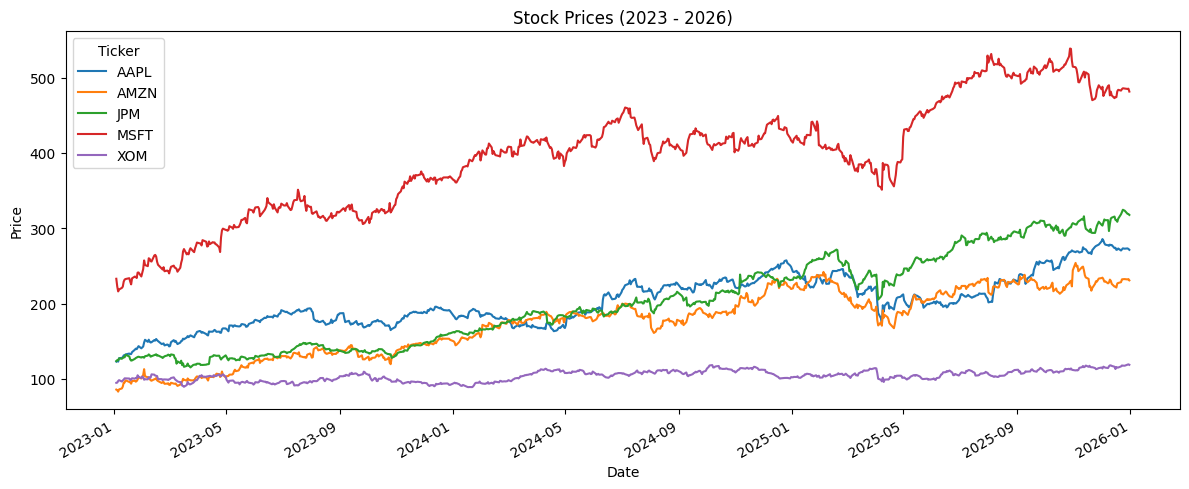

In [2]:
# Fetching data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# define portfolio
tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'XOM']
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])       # Equal weight means same amount of money invested in each stock

# download 3 years of adjusted closing prices
prices = yf.download(tickers, start = '2023-01-01', end = '2026-01-01', auto_adjust=True)['Close']

print(prices.shape)
display(prices.head())
print("\nMissing Values: ")
print(prices.isnull().sum())

# plot raw prices
prices.plot(figsize = (12,5), title = 'Stock Prices (2023 - 2026)')
plt.ylabel("Price")
plt.tight_layout()
plt.savefig('../data/stock_prices.png', dpi=150)
plt.show()

Daily returns (first 5 rows): 


Ticker,AAPL,AMZN,JPM,MSFT,XOM
Date,,,,,
2023-01-04,0.010314,-0.007924,0.009325,-0.043743,0.002910
2023-01-05,-0.010605,-0.023726,-0.000222,-0.029638,0.022374
2023-01-06,0.036794,0.035611,0.019136,0.011785,0.012087
2023-01-09,0.004089,0.014870,-0.004132,0.009736,-0.018637
2023-01-10,0.004456,0.028732,0.008954,0.007617,0.014935


Average daily return per stock: 
Ticker
AAPL    0.0012
AMZN    0.0015
JPM     0.0014
MSFT    0.0011
XOM     0.0004
dtype: float64

Portfolio daily return (first 5):
Date
2023-01-04   -0.005823
2023-01-05   -0.008363
2023-01-06    0.023083
2023-01-09    0.001185
2023-01-10    0.012939
Name: Portfolio, dtype: float64


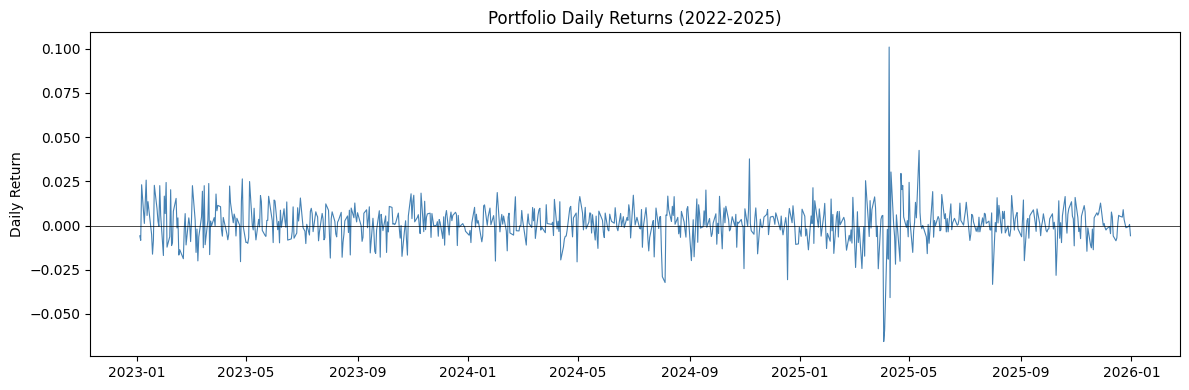

In [3]:
# Daily returns

# pct_change() calculates (today-yesterday)/yesterday for every row

daily_returns = prices.pct_change().dropna()

print("Daily returns (first 5 rows): ")
display(daily_returns.head())

print("Average daily return per stock: ")
print(daily_returns.mean().round(4))

# calculate portfolio return as the weighted average of all stock returns
portfolio_returns = daily_returns.dot(weights)
portfolio_returns.name = 'Portfolio'

print("\nPortfolio daily return (first 5):")
print(portfolio_returns.head())

# plot daily returns
plt.figure(figsize=(12,4))
plt.plot(portfolio_returns, color = 'steelblue', linewidth = 0.8)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.title('Portfolio Daily Returns (2022-2025)')
plt.ylabel('Daily Return')
plt.tight_layout()
plt.savefig('../data/daily_returns.png', dpi=150)
plt.show()

Cumulative returns: if we invested 1$ at the start, how much is it worth now

Formula: multipy (1 + daily_return) across every day

Example: 
1. Day 1 : +2% -> $1 x 1.02 = $1.02
2. Day 2 : -1% -> $1.02 x 0.99 = $1.01
3. Day 3 : +3% -> $1.01 x 1.03 = $1.04

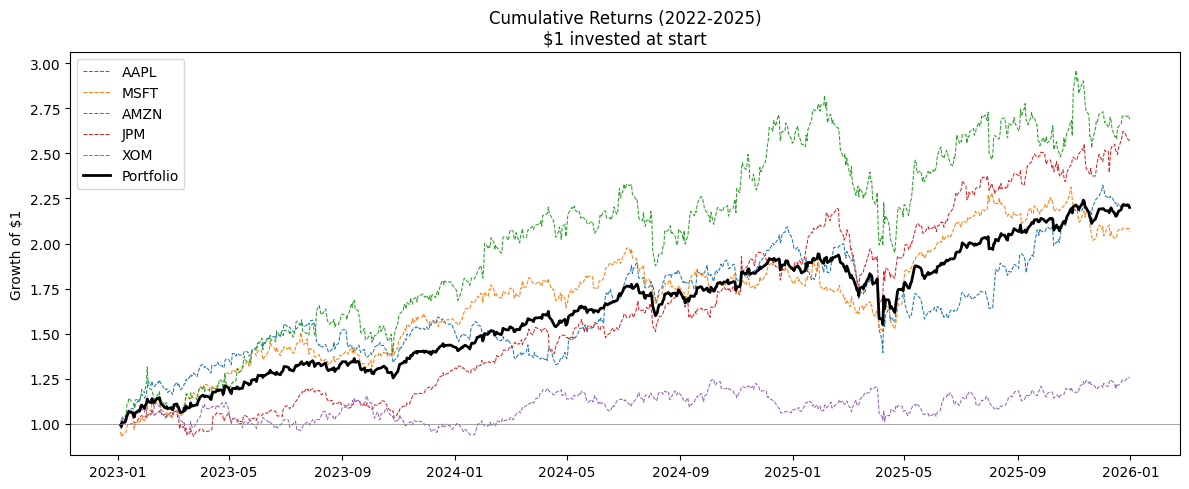

Total return over 3 years: 
AAPL :  120.6%
MSFT :  106.7%
AMZN :  169.0%
JPM :  156.8%
XOM :  25.3%
 Portfolio:  120.0%


In [ ]:
# Cumulative returns

cumulative = (1 + daily_returns).cumprod()
portfolio_cumulative = (1 + portfolio_returns).cumprod()

# plot each stock + portfolio cumulative return
plt.figure(figsize=(12,5))

for ticker in tickers:
    plt.plot(cumulative[ticker], linewidth = 0.75, label = ticker, linestyle = '--')

plt.plot(portfolio_cumulative, color = 'black', linewidth = 2, label = 'Portfolio')

plt.axhline(y = 1, color = 'gray', linewidth = 0.5)
plt.title('Cumulative Returns (2022-2025)\n$1 invested at start')
plt.ylabel('Growth of $1')
plt.legend()
plt.tight_layout()
plt.savefig('../data/cumulative_returns.png', dpi=150)
plt.show()

# print total return over 3 years 
print("Total return over 3 years: ")
for ticker in tickers:

    # get the final cumulative value and subtract 1 to get the total return
    total = cumulative[ticker].iloc[-1] - 1     # iloc[-1] returns the last value (last row) of a series or dataframe column.
    # print the stock ticker and its total return as a percentage
    print(f"{ticker} : {total: .1%}")

# print the portfolio's total return in the same way
print(f" Portfolio: {portfolio_cumulative.iloc[-1] - 1: .1%}")
